In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def compute_volume(df):
    # only for monoclinic...
    df['volume'] = df['a'] * df['b'] * df['c'] * np.sin(np.radians(df['beta'])) / 1000. # nm^3
    return

In [9]:
time_humid = pd.read_csv('./time_to_fishing.txt', sep='\s+', comment="#")
compute_volume(time_humid)
time_humid

,dataset,time,a,b,c,alpha,beta,gamma,biomtvol,wilson,volume
0,iheat_5999_05,5,114.359,53.579,44.621,90.0,100.909,90.0,81916.757,28.818,268.462937
1,iheat_5999_07,45,114.385,53.489,44.688,90.0,101.210,90.0,81622.741,34.987,268.199900
2,iheat_5999_08,65,113.675,53.374,44.707,90.0,102.474,90.0,81881.228,30.305,264.847208
3,iheat_5999_09,85,112.604,52.830,44.658,90.0,102.901,90.0,81563.854,30.648,258.958514
4,iheat_5999_10,105,113.074,52.926,44.806,90.0,102.782,90.0,81832.427,31.456,261.499050
5,iheat_5999_11,125,112.675,52.901,44.820,90.0,102.507,90.0,81807.165,28.243,260.815290
6,iheat_5999_13,165,110.640,54.049,46.187,90.0,102.372,90.0,82233.994,156.646,269.783295
7,iheat_5999_15,205,108.404,52.752,44.878,90.0,102.634,90.0,0.000,21.631,250.422198


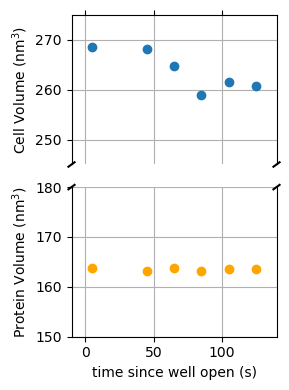

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(3, 4), sharex=False)
    
axes[0].spines['bottom'].set_visible(False)
axes[1].spines['top'].set_visible(False)
axes[0].xaxis.tick_top()
axes[0].tick_params(labeltop=False)  # don't put tick labels at the top
axes[1].xaxis.tick_bottom()

d = .015  # how big to make the diagonal lines in axes coordinates

kwargs = dict(transform=axes[0].transAxes, color='k', clip_on=False)
axes[0].plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
axes[0].plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=axes[1].transAxes)  # switch to the bottom axes
axes[1].plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
axes[1].plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

p1 = axes[0].plot(time_humid['time'], time_humid['volume'], 'o')
p2 = axes[1].plot(time_humid['time'], (time_humid['biomtvol'] / 1000. * 2.), 'o', color='orange')

axes[0].set_xlim([-10, 140])
axes[1].set_xlim([-10, 140])
axes[0].set_ylim([245, 275])
axes[1].set_ylim([150, 180])

axes[0].set_ylabel('Cell Volume (nm$^3$)')
axes[1].set_ylabel('Protein Volume (nm$^3$)')

axes[1].set_xlabel('time since well open (s)')

axes[0].grid()
axes[1].grid()

# axes[2].plot(time_humid['time'], time_humid['wilson'], 'o')
# axes[2].set_xlim([-10, 140])
# axes[2].set_ylim([15, 95])
# axes[2].set_xlabel('time since well open (s)')
# axes[2].set_ylabel('Wilson B ($\AA^{2}$)')

plt.tight_layout()
plt.savefig('./open_well_series.pdf')
plt.show()